# 03a_strategy_decision_generator

## Goal

This notebook extracts the **final strategy decision layer** from the larger basis+vol research workflow and exports a clean, stable decision file for Phase 3 execution-aware backtesting.

## Main responsibilities

1. Load the required research inputs
2. Build the basis dataframe from spot/futures bucket data
3. Merge auxiliary predicted-vol input
4. Apply the final basis+vol decision logic
5. Export a stable decision table

## Output

This notebook exports:

- `strategy_decisions_YYYYMMDD.parquet` for one day
- or `strategy_decisions_YYYYMMDD_YYYYMMDD.parquet` for a date range

with a stable schema, at minimum:

- `decision_time`
- `signal`

Recommended additional columns:

- `date`
- `basis_z`
- `basis_regime_flag`
- `pred_vol_30m`
- `pred_vol_filter_flag`
- `raw_basis_signal`

## Important note

This notebook is the **clean strategy decision generator**.
It should remain much smaller and cleaner than the exploratory research notebook.

In [20]:
# =========================================
# 1. Imports
# =========================================

from pathlib import Path
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Configuration

Edit this section first.

This notebook should make it easy to change:
- date range
- input paths
- final strategy parameters
- decision logic toggles

while keeping the exported decision schema stable.

In [35]:
# =========================================
# 1b. User Config
# =========================================

from pathlib import Path

DATA_ROOT = Path("/Volumes/profit")

# Research inputs
SPOT_BUCKETS_ROOT = DATA_ROOT / "feature_store" / "buckets"
FUT_BUCKETS_ROOT = DATA_ROOT / "feature_store_futures" / "buckets"
VOL_PRED_FILE = DATA_ROOT / "stat_arb_test" / "spot_vol_oos_pred_30m.parquet"

# Strategy output
STRATEGY_OUTPUT_ROOT = DATA_ROOT / "bitcoin_ticks" / "strategy_outputs"
STRATEGY_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Date selection
# Use either DATE_LIST, or DATE_FROM/DATE_TO
# -------------------------------------------------
DATE_LIST = []   # e.g. ["20251101", "20251103"]
DATE_FROM = "20251123"
DATE_TO   = "20251210"

# Final strategy setup (current preferred)
FREQ_MIN = 1
BASIS_Z_LOOKBACK = 120
ENTRY_Z = 1.5
EXIT_Z = 1.0

USE_BASIS_REGIME_FILTER = True
BASIS_REGIME_NAME = "basis_rv_30m_q90"

# vol prediction is only an auxiliary filter / confirmation signal
USE_PRED_VOL_FILTER = True
PRED_Q = 0.80
PRED_VOL_LOOKBACK_DAYS = 30
STRONG_Z = 2.75

FIGSIZE = (12, 5)

In [36]:
# =========================================
# 1c. Resolve target dates
# =========================================

def resolve_target_dates(date_list=None, date_from=None, date_to=None):
    if date_list is not None and len(date_list) > 0:
        return sorted(date_list)

    if date_from is None or date_to is None:
        raise ValueError("Need either DATE_LIST or both DATE_FROM and DATE_TO.")

    dates = pd.date_range(date_from, date_to, freq="D")
    return [d.strftime("%Y%m%d") for d in dates]

TARGET_DATES = resolve_target_dates(DATE_LIST, DATE_FROM, DATE_TO)

print("TARGET_DATES:", TARGET_DATES)

TARGET_DATES: ['20251123']


In [37]:
# =========================================
# 1d. Output filename
# =========================================

if len(TARGET_DATES) == 1:
    DECISION_OUTFILE = STRATEGY_OUTPUT_ROOT / f"strategy_decisions_{TARGET_DATES[0]}.parquet"
else:
    DECISION_OUTFILE = STRATEGY_OUTPUT_ROOT / f"strategy_decisions_{TARGET_DATES[0]}_{TARGET_DATES[-1]}.parquet"

print("DECISION_OUTFILE:", DECISION_OUTFILE)

DECISION_OUTFILE: /Volumes/profit/bitcoin_ticks/strategy_outputs/strategy_decisions_20251123.parquet


# 2. Quick path checks

Before running the notebook, verify that the input files exist.

In [38]:
# =========================================
# 2. Path sanity checks
# =========================================

print("DATA_ROOT exists         :", DATA_ROOT.exists(), DATA_ROOT)
print("SPOT_BUCKETS_ROOT exists :", SPOT_BUCKETS_ROOT.exists(), SPOT_BUCKETS_ROOT)
print("FUT_BUCKETS_ROOT exists  :", FUT_BUCKETS_ROOT.exists(), FUT_BUCKETS_ROOT)
print("VOL_PRED_FILE exists     :", VOL_PRED_FILE.exists(), VOL_PRED_FILE)
print("STRATEGY_OUTPUT_ROOT     :", STRATEGY_OUTPUT_ROOT)
print("DECISION_OUTFILE         :", DECISION_OUTFILE)

DATA_ROOT exists         : True /Volumes/profit
SPOT_BUCKETS_ROOT exists : True /Volumes/profit/feature_store/buckets
FUT_BUCKETS_ROOT exists  : True /Volumes/profit/feature_store_futures/buckets
VOL_PRED_FILE exists     : True /Volumes/profit/stat_arb_test/spot_vol_oos_pred_30m.parquet
STRATEGY_OUTPUT_ROOT     : /Volumes/profit/bitcoin_ticks/strategy_outputs
DECISION_OUTFILE         : /Volumes/profit/bitcoin_ticks/strategy_outputs/strategy_decisions_20251123.parquet


# 3. Load spot/futures bucket data for the selected dates

This notebook does **not** assume a precomputed basis parquet.

Instead, it reconstructs the research dataframe from:
- spot buckets
- futures buckets

using the same core basis-building logic as the research notebook.

In [17]:
# =========================================
# 3b. Bucket loading helpers (from research notebook)
# =========================================

def _date_range_yyyymmdd(start_date: str, end_date: str) -> List[str]:
    dates = pd.date_range(start=pd.Timestamp(start_date), end=pd.Timestamp(end_date), freq="D")
    return [d.strftime("%Y%m%d") for d in dates]


def load_bucket_range(
    buckets_root: str,
    freq_min: int,
    start_date: str,
    end_date: str,
    mid_col_prefer: str = "mid_last",
    px_fallback_col: str = "px_last",
    prefix: str = "spot",
) -> pd.DataFrame:
    """
    Load bucket parquet files over a date range and return a standardized dataframe.
    """
    dates = _date_range_yyyymmdd(start_date, end_date)

    frames = []
    for d in dates:
        path = os.path.join(buckets_root, f"freq={freq_min}min", f"date={d}", "buckets.parquet")
        if not os.path.exists(path):
            continue
        df = pd.read_parquet(path)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(
            f"No bucket parquet files found under {buckets_root} for [{start_date}, {end_date}]"
        )

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values("timestamp").drop_duplicates(subset=["timestamp"], keep="last").reset_index(drop=True)

    px = df[mid_col_prefer].copy() if mid_col_prefer in df.columns else pd.Series(np.nan, index=df.index)
    if px_fallback_col in df.columns:
        px = px.fillna(df[px_fallback_col])
    px = px.ffill()

    out = pd.DataFrame({
        "timestamp": pd.to_datetime(df["timestamp"], utc=True),
        f"{prefix}_mid": px.astype(float),
    })

    extra_cols = [
        "mid_last",
        "px_last",
        "vol_notional",
        "n_trades",
        "buy_ratio",
        "rel_spread_mean",
        "imbalance_mean",
    ]
    for c in extra_cols:
        if c in df.columns:
            out[f"{prefix}_{c}"] = df[c].values

    return out

# 4. Reuse core basis construction logic

Paste the minimal versions of the following research functions here:

- `prepare_basis_dataframe(...)`
- `add_basis_specific_signals(...)`

Keep them as close as possible to the research notebook implementation.

In [18]:
# =========================================
# 4. Exact basis construction logic (from research notebook)
# =========================================

def prepare_basis_dataframe(
    spot_buckets_root: str,
    fut_buckets_root: str,
    freq_min: int,
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    """
    Load spot and futures buckets, align on timestamp, and construct basis dataframe.
    """
    spot = load_bucket_range(
        buckets_root=spot_buckets_root,
        freq_min=freq_min,
        start_date=start_date,
        end_date=end_date,
        prefix="spot",
    )
    fut = load_bucket_range(
        buckets_root=fut_buckets_root,
        freq_min=freq_min,
        start_date=start_date,
        end_date=end_date,
        prefix="fut",
    )

    df = (
        spot.merge(fut, on="timestamp", how="inner")
            .sort_values("timestamp")
            .drop_duplicates(subset=["timestamp"], keep="last")
            .reset_index(drop=True)
    )

    df["log_spot"] = np.log(df["spot_mid"].replace(0, np.nan))
    df["log_fut"] = np.log(df["fut_mid"].replace(0, np.nan))

    df["ret_spot"] = df["log_spot"].diff()
    df["ret_fut"] = df["log_fut"].diff()

    df["basis"] = df["log_fut"] - df["log_spot"]
    df["basis_ret"] = df["basis"].diff()

    return df


def add_basis_specific_signals(
    df: pd.DataFrame,
    freq_min: int = 1,
    basis_vol_horizon_min: int = 30,
    div_horizon_min: int = 30,
) -> pd.DataFrame:
    out = df.copy()

    Wb = int(round(basis_vol_horizon_min / freq_min))
    Wd = int(round(div_horizon_min / freq_min))

    out["basis_vol_30m"] = out["basis_ret"].pow(2).rolling(Wb, min_periods=Wb).sum()
    out["basis_rv_30m"] = out["basis_ret"].pow(2).rolling(Wb, min_periods=Wb).sum()

    out["div_30m_mean"] = out["basis"].abs().rolling(Wd, min_periods=Wd).mean()
    out["div_30m_max"] = out["basis"].abs().rolling(Wd, min_periods=Wd).max()

    return out

# 5. Build basis dataframe exactly as in the research workflow

This is the core market dataframe used to generate the final strategy signal.

In [39]:
# =========================================
# 5. Build basis dataframe using research workflow
# =========================================

df_mkt = prepare_basis_dataframe(
    spot_buckets_root=str(SPOT_BUCKETS_ROOT),
    fut_buckets_root=str(FUT_BUCKETS_ROOT),
    freq_min=FREQ_MIN,
    start_date=TARGET_DATES[0],
    end_date=TARGET_DATES[-1],
)

df_mkt = add_basis_specific_signals(
    df_mkt,
    freq_min=FREQ_MIN,
    basis_vol_horizon_min=30,
    div_horizon_min=30,
)

# add date column for downstream filtering / export consistency
df_mkt["date"] = df_mkt["timestamp"].dt.strftime("%Y%m%d")

print("df_mkt shape:", df_mkt.shape)
display(df_mkt.head(5))

print("df_mkt columns:")
print(list(df_mkt.columns))

df_mkt shape: (1441, 28)


,timestamp,spot_mid,spot_mid_last,spot_px_last,spot_vol_notional,spot_n_trades,spot_buy_ratio,spot_rel_spread_mean,spot_imbalance_mean,fut_mid,...,log_fut,ret_spot,ret_fut,basis,basis_ret,basis_vol_30m,basis_rv_30m,div_30m_mean,div_30m_max,date
0,2025-11-23 00:00:00+00:00,84688.005,84688.005,84688.01,7.637276e+05,609,0.508207,4.852011e-07,-0.755478,84639.35,...,11.346155,NaN,NaN,-0.000575,NaN,NaN,NaN,NaN,NaN,20251123
1,2025-11-23 00:01:00+00:00,84804.000,84804.000,84792.97,8.000480e+05,1068,0.674792,9.305162e-07,0.383145,84749.45,...,11.347455,0.001369,0.001300,-0.000643,-0.000069,NaN,NaN,NaN,NaN,20251123
2,2025-11-23 00:02:00+00:00,84877.245,84877.245,84877.24,1.722741e+06,920,0.918031,8.454020e-07,0.161706,84829.45,...,11.348398,0.000863,0.000944,-0.000563,0.000080,NaN,NaN,NaN,NaN,20251123
3,2025-11-23 00:03:00+00:00,84941.255,84941.255,84943.08,2.708201e+06,1365,0.897390,1.061509e-06,0.072669,84910.95,...,11.349358,0.000754,0.000960,-0.000357,0.000206,NaN,NaN,NaN,NaN,20251123
4,2025-11-23 00:04:00+00:00,84914.255,84914.255,84919.73,4.452266e+05,637,0.413809,4.702317e-07,0.125233,84887.35,...,11.349080,-0.000318,-0.000278,-0.000317,0.000040,NaN,NaN,NaN,NaN,20251123


df_mkt columns:
['timestamp', 'spot_mid', 'spot_mid_last', 'spot_px_last', 'spot_vol_notional', 'spot_n_trades', 'spot_buy_ratio', 'spot_rel_spread_mean', 'spot_imbalance_mean', 'fut_mid', 'fut_mid_last', 'fut_px_last', 'fut_vol_notional', 'fut_n_trades', 'fut_buy_ratio', 'fut_rel_spread_mean', 'fut_imbalance_mean', 'log_spot', 'log_fut', 'ret_spot', 'ret_fut', 'basis', 'basis_ret', 'basis_vol_30m', 'basis_rv_30m', 'div_30m_mean', 'div_30m_max', 'date']


# 6. Load and filter predicted-vol input

`vol_pred_30m.parquet` is used only as an auxiliary filter / confirmation signal.

In [40]:
# =========================================
# 6. Load and filter vol prediction input
# =========================================

vol_df = pd.read_parquet(VOL_PRED_FILE) if VOL_PRED_FILE.exists() else pd.DataFrame()

print("vol_df raw shape:", vol_df.shape)
if len(vol_df) > 0:
    display(vol_df.head(5))

if len(vol_df) > 0:
    if "timestamp" not in vol_df.columns:
        for c in ["time", "event_time", "ts", "datetime", "date_time"]:
            if c in vol_df.columns:
                vol_df["timestamp"] = vol_df[c]
                break

    # normalize to UTC datetime to match df_mkt
    vol_df["timestamp"] = pd.to_datetime(vol_df["timestamp"], utc=True)

    if "date" not in vol_df.columns:
        vol_df["date"] = vol_df["timestamp"].dt.strftime("%Y%m%d")

    vol_df = vol_df[vol_df["date"].isin(TARGET_DATES)].copy()

print("vol_df filtered shape:", vol_df.shape)
if len(vol_df) > 0:
    display(vol_df.head(5))

print("vol_df columns:")
print(list(vol_df.columns))

vol_df raw shape: (149178, 3)


,timestamp,y_30m,pred_y_30m
0,2025-11-21 00:30:00+00:00,-10.819157,-10.564773
1,2025-11-21 00:31:00+00:00,-10.822318,-10.517735
2,2025-11-21 00:32:00+00:00,-11.023323,-10.397844
3,2025-11-21 00:33:00+00:00,-11.005065,-10.371121
4,2025-11-21 00:34:00+00:00,-10.938123,-10.316741


vol_df filtered shape: (1381, 4)


,timestamp,y_30m,pred_y_30m,date
2790,2025-11-23 00:59:00+00:00,-11.433720,-11.492419,20251123
2791,2025-11-23 01:00:00+00:00,-11.460750,-11.610743,20251123
2792,2025-11-23 01:01:00+00:00,-11.479005,-11.654127,20251123
2793,2025-11-23 01:02:00+00:00,-11.631954,-11.637144,20251123
2794,2025-11-23 01:03:00+00:00,-11.820051,-11.509429,20251123


vol_df columns:
['timestamp', 'y_30m', 'pred_y_30m', 'date']


# 7. Merge auxiliary vol predictions onto the basis timeline

The basis-side market dataframe remains the master timeline.
Vol predictions are merged backward onto it.

In [41]:
# =========================================
# 7. Merge vol predictions onto basis timeline
# =========================================

if len(df_mkt) > 0:
    df_mkt = df_mkt.sort_values("timestamp").reset_index(drop=True)

if len(vol_df) > 0:
    vol_df = vol_df.sort_values("timestamp").reset_index(drop=True)

if len(df_mkt) > 0 and len(vol_df) > 0:
    merged = pd.merge_asof(
        df_mkt,
        vol_df,
        on="timestamp",
        direction="backward",
        suffixes=("", "_vol"),
    )
else:
    merged = df_mkt.copy()

print("merged shape:", merged.shape)
if len(merged) > 0:
    display(merged.head(5))

print("merged columns:")
print(list(merged.columns))

merged shape: (1441, 31)


,timestamp,spot_mid,spot_mid_last,spot_px_last,spot_vol_notional,spot_n_trades,spot_buy_ratio,spot_rel_spread_mean,spot_imbalance_mean,fut_mid,...,basis,basis_ret,basis_vol_30m,basis_rv_30m,div_30m_mean,div_30m_max,date,y_30m,pred_y_30m,date_vol
0,2025-11-23 00:00:00+00:00,84688.005,84688.005,84688.01,7.637276e+05,609,0.508207,4.852011e-07,-0.755478,84639.35,...,-0.000575,NaN,NaN,NaN,NaN,NaN,20251123,NaN,NaN,NaN
1,2025-11-23 00:01:00+00:00,84804.000,84804.000,84792.97,8.000480e+05,1068,0.674792,9.305162e-07,0.383145,84749.45,...,-0.000643,-0.000069,NaN,NaN,NaN,NaN,20251123,NaN,NaN,NaN
2,2025-11-23 00:02:00+00:00,84877.245,84877.245,84877.24,1.722741e+06,920,0.918031,8.454020e-07,0.161706,84829.45,...,-0.000563,0.000080,NaN,NaN,NaN,NaN,20251123,NaN,NaN,NaN
3,2025-11-23 00:03:00+00:00,84941.255,84941.255,84943.08,2.708201e+06,1365,0.897390,1.061509e-06,0.072669,84910.95,...,-0.000357,0.000206,NaN,NaN,NaN,NaN,20251123,NaN,NaN,NaN
4,2025-11-23 00:04:00+00:00,84914.255,84914.255,84919.73,4.452266e+05,637,0.413809,4.702317e-07,0.125233,84887.35,...,-0.000317,0.000040,NaN,NaN,NaN,NaN,20251123,NaN,NaN,NaN


merged columns:
['timestamp', 'spot_mid', 'spot_mid_last', 'spot_px_last', 'spot_vol_notional', 'spot_n_trades', 'spot_buy_ratio', 'spot_rel_spread_mean', 'spot_imbalance_mean', 'fut_mid', 'fut_mid_last', 'fut_px_last', 'fut_vol_notional', 'fut_n_trades', 'fut_buy_ratio', 'fut_rel_spread_mean', 'fut_imbalance_mean', 'log_spot', 'log_fut', 'ret_spot', 'ret_fut', 'basis', 'basis_ret', 'basis_vol_30m', 'basis_rv_30m', 'div_30m_mean', 'div_30m_max', 'date', 'y_30m', 'pred_y_30m', 'date_vol']


# 8. Strategy input adapter

The goal is to standardize the columns needed by the final strategy logic:

- `basis_z`
- `basis_regime_flag`
- `pred_vol_30m`
- `pred_vol_filter_flag`

This is where you adapt to your real research-input schema if needed.

In [42]:
# =========================================
# 8a. Build basis_z from basis
# =========================================

if len(strategy_df) > 0:
    rolling_mean = strategy_df["basis"].rolling(BASIS_Z_LOOKBACK, min_periods=BASIS_Z_LOOKBACK).mean()
    rolling_std = strategy_df["basis"].rolling(BASIS_Z_LOOKBACK, min_periods=BASIS_Z_LOOKBACK).std()

    strategy_df["basis_z"] = (strategy_df["basis"] - rolling_mean) / rolling_std

    print("basis_z added.")
    display(strategy_df[["timestamp", "basis", "basis_z"]].head(15))

basis_z added.


,timestamp,basis,basis_z
0,2025-11-01 00:00:00+00:00,-0.000401,NaN
1,2025-11-01 00:01:00+00:00,-0.000395,NaN
2,2025-11-01 00:02:00+00:00,-0.000405,NaN
3,2025-11-01 00:03:00+00:00,-0.000257,NaN
4,2025-11-01 00:04:00+00:00,-0.000360,NaN
5,2025-11-01 00:05:00+00:00,-0.000272,NaN
6,2025-11-01 00:06:00+00:00,-0.000368,NaN
7,2025-11-01 00:07:00+00:00,-0.000403,NaN
8,2025-11-01 00:08:00+00:00,-0.000398,NaN
9,2025-11-01 00:09:00+00:00,-0.000339,NaN


In [46]:
# =========================================
# 8a. Standardize strategy input columns
# =========================================

strategy_df = merged.copy()

if len(strategy_df) == 0:
    print("strategy_df is empty.")
else:
    # -------------------------------------------------
    # build basis_z if missing
    # -------------------------------------------------
    if "basis_z" not in strategy_df.columns:
        if "basis" not in strategy_df.columns:
            raise ValueError("Need 'basis' column to construct basis_z.")

        rolling_mean = strategy_df["basis"].rolling(
            BASIS_Z_LOOKBACK, min_periods=BASIS_Z_LOOKBACK
        ).mean()
        rolling_std = strategy_df["basis"].rolling(
            BASIS_Z_LOOKBACK, min_periods=BASIS_Z_LOOKBACK
        ).std()

        strategy_df["basis_z"] = (strategy_df["basis"] - rolling_mean) / rolling_std

    # -------------------------------------------------
    # basis regime flag
    # -------------------------------------------------
    if USE_BASIS_REGIME_FILTER:
        if "basis_regime_flag" not in strategy_df.columns:
            if "basis_rv_30m_q90_flag" in strategy_df.columns:
                strategy_df["basis_regime_flag"] = strategy_df["basis_rv_30m_q90_flag"].astype(bool)
            elif "basis_rv_30m" in strategy_df.columns:
                q90 = strategy_df["basis_rv_30m"].quantile(0.90)
                strategy_df["basis_regime_flag"] = strategy_df["basis_rv_30m"] >= q90
            else:
                raise ValueError("Need 'basis_rv_30m' (or a prebuilt basis regime flag).")
    else:
        strategy_df["basis_regime_flag"] = True

    strategy_df["basis_regime_flag"] = strategy_df["basis_regime_flag"].fillna(False).astype(bool)

    # -------------------------------------------------
    # predicted vol
    # -------------------------------------------------
    if USE_PRED_VOL_FILTER:
        if "pred_y_30m" not in strategy_df.columns:
            raise ValueError("Need 'pred_y_30m' column after merging vol predictions.")

        strategy_df["pred_vol_30m"] = pd.to_numeric(strategy_df["pred_y_30m"], errors="coerce")

        # temporary sample-quantile proxy
        pred_q_threshold = strategy_df["pred_vol_30m"].quantile(PRED_Q)
        strategy_df["pred_vol_filter_flag"] = strategy_df["pred_vol_30m"] >= pred_q_threshold
    else:
        strategy_df["pred_vol_30m"] = np.nan
        strategy_df["pred_vol_filter_flag"] = False

    strategy_df["pred_vol_filter_flag"] = strategy_df["pred_vol_filter_flag"].fillna(False).astype(bool)

    display(strategy_df[[
        "timestamp", "basis", "basis_z", "basis_rv_30m", "basis_regime_flag",
        "pred_vol_30m", "pred_vol_filter_flag"
    ]].head(10))

,timestamp,basis,basis_z,basis_rv_30m,basis_regime_flag,pred_vol_30m,pred_vol_filter_flag
0,2025-11-23 00:00:00+00:00,-0.000575,NaN,NaN,False,NaN,False
1,2025-11-23 00:01:00+00:00,-0.000643,NaN,NaN,False,NaN,False
2,2025-11-23 00:02:00+00:00,-0.000563,NaN,NaN,False,NaN,False
3,2025-11-23 00:03:00+00:00,-0.000357,NaN,NaN,False,NaN,False
4,2025-11-23 00:04:00+00:00,-0.000317,NaN,NaN,False,NaN,False
5,2025-11-23 00:05:00+00:00,-0.000389,NaN,NaN,False,NaN,False
6,2025-11-23 00:06:00+00:00,-0.000502,NaN,NaN,False,NaN,False
7,2025-11-23 00:07:00+00:00,-0.000473,NaN,NaN,False,NaN,False
8,2025-11-23 00:08:00+00:00,-0.000434,NaN,NaN,False,NaN,False
9,2025-11-23 00:09:00+00:00,-0.000478,NaN,NaN,False,NaN,False


# 9. Final basis+vol decision logic

This notebook uses the current preferred logic:

- basis signal is the main directional signal
- basis regime filter is the outer filter
- predicted vol is used only as an auxiliary confirmation for marginal trades

In [49]:
# =========================================
# 9. Build final signal path
# =========================================

def build_final_signal(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if len(out) == 0:
        return out

    # raw basis signal from z-score
    out["raw_basis_signal"] = 0
    out.loc[out["basis_z"] >= ENTRY_Z, "raw_basis_signal"] = -1
    out.loc[out["basis_z"] <= -ENTRY_Z, "raw_basis_signal"] = 1

    # apply outer basis regime filter
    if USE_BASIS_REGIME_FILTER:
        out.loc[~out["basis_regime_flag"], "raw_basis_signal"] = 0

    # predicted vol only filters marginal trades
    if USE_PRED_VOL_FILTER:
        strong_trade = out["basis_z"].abs() >= STRONG_Z
        marginal_trade = (out["raw_basis_signal"] != 0) & (~strong_trade)
        out.loc[marginal_trade & (~out["pred_vol_filter_flag"]), "raw_basis_signal"] = 0

    # persistent signal with exit band
    signal = []
    current = 0

    for _, row in out.iterrows():
        raw = int(row["raw_basis_signal"])

        if pd.notna(row["basis_z"]) and abs(row["basis_z"]) <= EXIT_Z:
            current = 0
        elif raw != 0:
            current = raw

        signal.append(current)

    out["signal"] = signal
    return out

strategy_df = build_final_signal(strategy_df)

print("strategy_df shape:", strategy_df.shape)
if len(strategy_df) > 0:
    display(strategy_df[[
        "timestamp",
        "date",
        "basis_z",
        "basis_regime_flag",
        "pred_vol_filter_flag",
        "raw_basis_signal",
        "signal"
    ]].head(130))

strategy_df shape: (1441, 37)


,timestamp,date,basis_z,basis_regime_flag,pred_vol_filter_flag,raw_basis_signal,signal
0,2025-11-23 00:00:00+00:00,20251123,NaN,False,False,0,0
1,2025-11-23 00:01:00+00:00,20251123,NaN,False,False,0,0
2,2025-11-23 00:02:00+00:00,20251123,NaN,False,False,0,0
3,2025-11-23 00:03:00+00:00,20251123,NaN,False,False,0,0
4,2025-11-23 00:04:00+00:00,20251123,NaN,False,False,0,0
...,...,...,...,...,...,...,...
125,2025-11-23 02:05:00+00:00,20251123,0.884101,True,True,0,0
126,2025-11-23 02:06:00+00:00,20251123,-0.551980,True,True,0,0
127,2025-11-23 02:07:00+00:00,20251123,-0.127111,True,True,0,0
128,2025-11-23 02:08:00+00:00,20251123,-0.881489,True,True,0,0


In [50]:
print("basis_z non-null count:", strategy_df["basis_z"].notna().sum())
print("basis_z first valid index:", strategy_df["basis_z"].first_valid_index())

display(
    strategy_df.loc[
        strategy_df["basis_z"].notna(),
        ["timestamp", "basis", "basis_z"]
    ].head(10)
)

basis_z non-null count: 1322
basis_z first valid index: 119


,timestamp,basis,basis_z
119,2025-11-23 01:59:00+00:00,-0.000570,-0.332963
120,2025-11-23 02:00:00+00:00,-0.000649,-0.875252
121,2025-11-23 02:01:00+00:00,-0.000618,-0.665899
122,2025-11-23 02:02:00+00:00,-0.000709,-1.283993
123,2025-11-23 02:03:00+00:00,-0.000578,-0.364931
124,2025-11-23 02:04:00+00:00,-0.000530,-0.013917
125,2025-11-23 02:05:00+00:00,-0.000402,0.884101
126,2025-11-23 02:06:00+00:00,-0.000607,-0.551980
127,2025-11-23 02:07:00+00:00,-0.000547,-0.127111
128,2025-11-23 02:08:00+00:00,-0.000657,-0.881489


In [51]:
print("basis_regime_flag distribution:")
display(strategy_df["basis_regime_flag"].value_counts(dropna=False))

basis_regime_flag distribution:


basis_regime_flag
False    1299
True      142
Name: count, dtype: int64

In [52]:
print("raw_basis_signal distribution:")
display(strategy_df["raw_basis_signal"].value_counts(dropna=False).sort_index())

print("signal distribution:")
display(strategy_df["signal"].value_counts(dropna=False).sort_index())

raw_basis_signal distribution:


raw_basis_signal
-1       6
 0    1431
 1       4
Name: count, dtype: int64

signal distribution:


signal
-1       8
 0    1428
 1       5
Name: count, dtype: int64

In [53]:
sample_true = strategy_df.loc[strategy_df["basis_regime_flag"]].copy()

display(sample_true[[
    "timestamp",
    "basis",
    "basis_z",
    "basis_rv_30m",
    "basis_regime_flag",
    "pred_vol_30m",
    "pred_vol_filter_flag",
    "raw_basis_signal",
    "signal"
]].head(30))

,timestamp,basis,basis_z,basis_rv_30m,basis_regime_flag,pred_vol_30m,pred_vol_filter_flag,raw_basis_signal,signal
114,2025-11-23 01:54:00+00:00,0.000318,NaN,0.000004,True,-10.808605,True,0,0
115,2025-11-23 01:55:00+00:00,-0.000520,NaN,0.000005,True,-10.800979,True,0,0
116,2025-11-23 01:56:00+00:00,-0.000545,NaN,0.000005,True,-10.781380,True,0,0
117,2025-11-23 01:57:00+00:00,-0.000563,NaN,0.000005,True,-10.725291,True,0,0
118,2025-11-23 01:58:00+00:00,-0.000209,NaN,0.000005,True,-10.792934,True,0,0
119,2025-11-23 01:59:00+00:00,-0.000570,-0.332963,0.000005,True,-10.930887,True,0,0
120,2025-11-23 02:00:00+00:00,-0.000649,-0.875252,0.000005,True,-10.916415,True,0,0
121,2025-11-23 02:01:00+00:00,-0.000618,-0.665899,0.000005,True,-10.951194,True,0,0
122,2025-11-23 02:02:00+00:00,-0.000709,-1.283993,0.000005,True,-10.836583,True,0,0
123,2025-11-23 02:03:00+00:00,-0.000578,-0.364931,0.000005,True,-10.825627,True,0,0


# 10. Build clean decision table

This is the key output handoff into Phase 3.

The schema should remain stable even if you tweak internal strategy logic.

In [55]:
# =========================================
# 10. Build clean decision table
# =========================================

required_cols = [
    "timestamp",
    "date",
    "basis_z",
    "basis_regime_flag",
    "pred_vol_30m",
    "pred_vol_filter_flag",
    "raw_basis_signal",
    "signal",
]

missing_cols = [c for c in required_cols if c not in strategy_df.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns for decision export: {missing_cols}")

decisions = strategy_df[required_cols].copy()
decisions = decisions.rename(columns={"timestamp": "decision_time"})
decisions = decisions.sort_values("decision_time").reset_index(drop=True)

print("decisions shape:", decisions.shape)
display(decisions.head(130))

decisions shape: (1441, 8)


,decision_time,date,basis_z,basis_regime_flag,pred_vol_30m,pred_vol_filter_flag,raw_basis_signal,signal
0,2025-11-23 00:00:00+00:00,20251123,NaN,False,NaN,False,0,0
1,2025-11-23 00:01:00+00:00,20251123,NaN,False,NaN,False,0,0
2,2025-11-23 00:02:00+00:00,20251123,NaN,False,NaN,False,0,0
3,2025-11-23 00:03:00+00:00,20251123,NaN,False,NaN,False,0,0
4,2025-11-23 00:04:00+00:00,20251123,NaN,False,NaN,False,0,0
...,...,...,...,...,...,...,...,...
125,2025-11-23 02:05:00+00:00,20251123,0.884101,True,-10.827250,True,0,0
126,2025-11-23 02:06:00+00:00,20251123,-0.551980,True,-10.769203,True,0,0
127,2025-11-23 02:07:00+00:00,20251123,-0.127111,True,-10.699713,True,0,0
128,2025-11-23 02:08:00+00:00,20251123,-0.881489,True,-10.692462,True,0,0


# 11. Quick sanity checks

These checks are useful before exporting the decision parquet.

In [56]:
# =========================================
# 11a. Signal distribution
# =========================================

print("Signal distribution:")
display(decisions["signal"].value_counts(dropna=False).sort_index())

Signal distribution:


signal
-1       8
 0    1428
 1       5
Name: count, dtype: int64

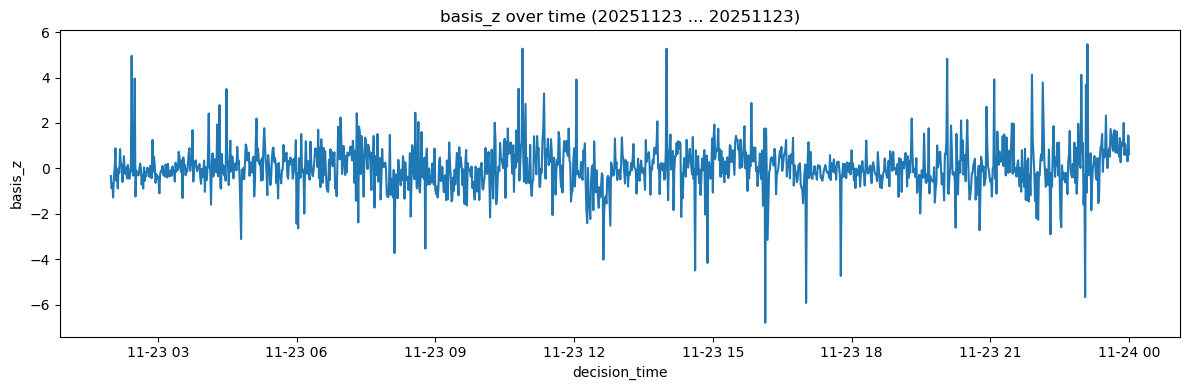

In [57]:
# =========================================
# 11b. basis_z over time
# =========================================

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(decisions["decision_time"], decisions["basis_z"])
ax.set_title(f"basis_z over time ({TARGET_DATES[0]} ... {TARGET_DATES[-1]})")
ax.set_xlabel("decision_time")
ax.set_ylabel("basis_z")
plt.tight_layout()
plt.show()

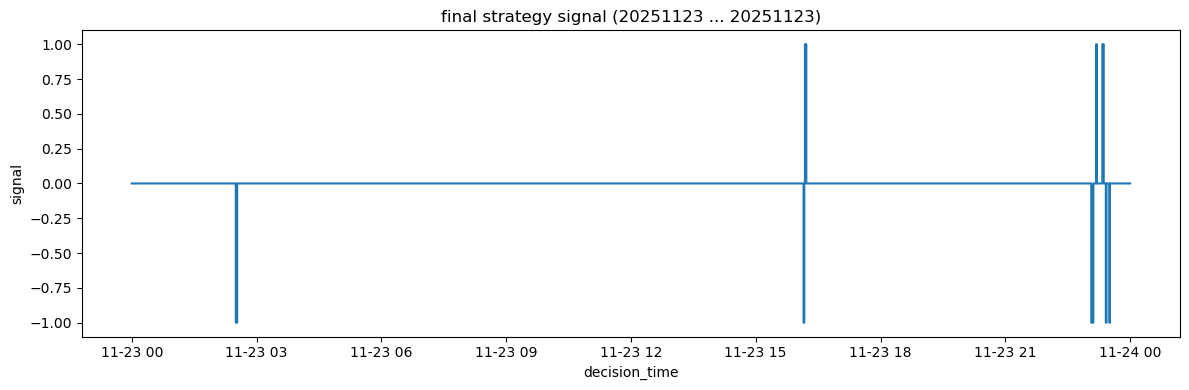

In [58]:
# =========================================
# 11c. Final signal over time
# =========================================

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(decisions["decision_time"], decisions["signal"], drawstyle="steps-post")
ax.set_title(f"final strategy signal ({TARGET_DATES[0]} ... {TARGET_DATES[-1]})")
ax.set_xlabel("decision_time")
ax.set_ylabel("signal")
plt.tight_layout()
plt.show()

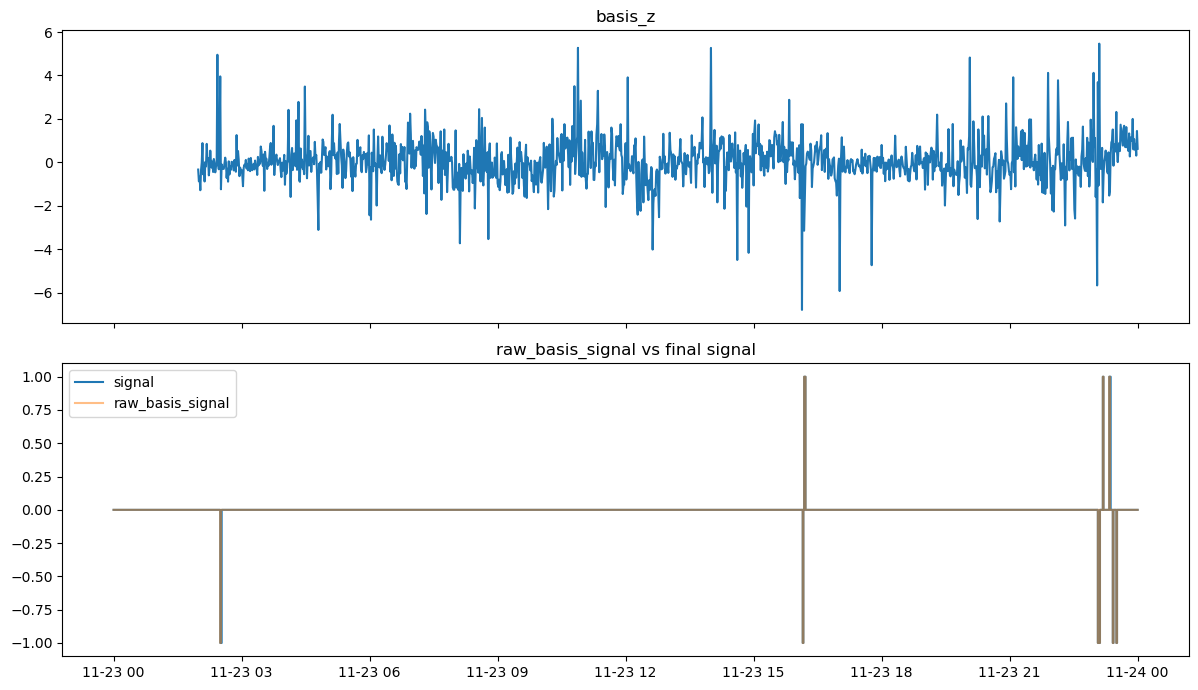

In [59]:
# =========================================
# 11d. raw_basis_signal vs final signal
# =========================================

if len(decisions) > 0:
    tmp = decisions.copy()

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axes[0].plot(tmp["decision_time"], tmp["basis_z"])
    axes[0].set_title("basis_z")

    axes[1].plot(tmp["decision_time"], tmp["signal"], drawstyle="steps-post", label="signal")
    axes[1].plot(tmp["decision_time"], tmp["raw_basis_signal"], alpha=0.5, drawstyle="steps-post", label="raw_basis_signal")
    axes[1].set_title("raw_basis_signal vs final signal")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# 12. Save decision parquet

This exported file is the stable handoff into Phase 3 execution-aware backtesting.

In [61]:
# =========================================
# 12. Save decision parquet
# =========================================

decisions.to_parquet(DECISION_OUTFILE, index=False)

print("Saved decision file:")
print(DECISION_OUTFILE)

Saved decision file:
/Volumes/profit/bitcoin_ticks/strategy_outputs/strategy_decisions_20251123.parquet


# 13. Summary

This notebook intentionally does only one job:

- convert the final basis+vol strategy logic into a clean, stable decision table

This decision table is the stable bridge into Phase 3 execution-aware backtesting.

In [45]:
# Inspect merged columns to find the vol prediction column
print("strategy_df columns:")
print(list(strategy_df.columns))

strategy_df columns:
['timestamp', 'spot_mid', 'spot_mid_last', 'spot_px_last', 'spot_vol_notional', 'spot_n_trades', 'spot_buy_ratio', 'spot_rel_spread_mean', 'spot_imbalance_mean', 'fut_mid', 'fut_mid_last', 'fut_px_last', 'fut_vol_notional', 'fut_n_trades', 'fut_buy_ratio', 'fut_rel_spread_mean', 'fut_imbalance_mean', 'log_spot', 'log_fut', 'ret_spot', 'ret_fut', 'basis', 'basis_ret', 'basis_vol_30m', 'basis_rv_30m', 'div_30m_mean', 'div_30m_max', 'date', 'y_30m', 'pred_y_30m', 'date_vol', 'basis_z', 'basis_regime_flag']


In [33]:
# =========================================
# DEBUG: inspect vol_df and merged before strategy input standardization
# =========================================

print("vol_df shape:", vol_df.shape)
if len(vol_df) > 0:
    display(vol_df.head(5))
    print("vol_df columns:")
    print(list(vol_df.columns))
    print("vol_df timestamp dtype:", vol_df["timestamp"].dtype)
    print("vol_df timestamp min/max:", vol_df["timestamp"].min(), vol_df["timestamp"].max())
    if "date" in vol_df.columns:
        print("vol_df unique dates:", sorted(vol_df["date"].astype(str).unique())[:10])

print("\ndf_mkt shape:", df_mkt.shape)
if len(df_mkt) > 0:
    print("df_mkt timestamp dtype:", df_mkt["timestamp"].dtype)
    print("df_mkt timestamp min/max:", df_mkt["timestamp"].min(), df_mkt["timestamp"].max())

print("\nmerged shape:", merged.shape)
if len(merged) > 0:
    print("merged columns:")
    print(list(merged.columns))

vol_df shape: (0, 4)

df_mkt shape: (1441, 28)
df_mkt timestamp dtype: datetime64[ns, UTC]
df_mkt timestamp min/max: 2025-11-01 00:00:00+00:00 2025-11-02 00:00:00+00:00

merged shape: (1441, 28)
merged columns:
['timestamp', 'spot_mid', 'spot_mid_last', 'spot_px_last', 'spot_vol_notional', 'spot_n_trades', 'spot_buy_ratio', 'spot_rel_spread_mean', 'spot_imbalance_mean', 'fut_mid', 'fut_mid_last', 'fut_px_last', 'fut_vol_notional', 'fut_n_trades', 'fut_buy_ratio', 'fut_rel_spread_mean', 'fut_imbalance_mean', 'log_spot', 'log_fut', 'ret_spot', 'ret_fut', 'basis', 'basis_ret', 'basis_vol_30m', 'basis_rv_30m', 'div_30m_mean', 'div_30m_max', 'date']


In [34]:
# Re-read raw vol file without date filtering, just inspect
vol_raw = pd.read_parquet(VOL_PRED_FILE)

print("vol_raw shape:", vol_raw.shape)
display(vol_raw.head(10))
print("vol_raw columns:", list(vol_raw.columns))
print("\nvol_raw dtypes:")
print(vol_raw.dtypes)

for c in ["timestamp", "time", "event_time", "ts", "datetime", "date_time", "date"]:
    if c in vol_raw.columns:
        print(f"\nColumn '{c}' sample:")
        print(vol_raw[c].head(10).tolist())

vol_raw shape: (149178, 3)


,timestamp,y_30m,pred_y_30m
0,2025-11-21 00:30:00+00:00,-10.819157,-10.564773
1,2025-11-21 00:31:00+00:00,-10.822318,-10.517735
2,2025-11-21 00:32:00+00:00,-11.023323,-10.397844
3,2025-11-21 00:33:00+00:00,-11.005065,-10.371121
4,2025-11-21 00:34:00+00:00,-10.938123,-10.316741
5,2025-11-21 00:35:00+00:00,-10.939646,-10.321449
6,2025-11-21 00:36:00+00:00,-10.961239,-10.360311
7,2025-11-21 00:37:00+00:00,-10.968167,-10.455342
8,2025-11-21 00:38:00+00:00,-11.030609,-10.491322
9,2025-11-21 00:39:00+00:00,-11.030031,-10.434189


vol_raw columns: ['timestamp', 'y_30m', 'pred_y_30m']

vol_raw dtypes:
timestamp     datetime64[ns, UTC]
y_30m                     float64
pred_y_30m                float64
dtype: object

Column 'timestamp' sample:
[Timestamp('2025-11-21 00:30:00+0000', tz='UTC'), Timestamp('2025-11-21 00:31:00+0000', tz='UTC'), Timestamp('2025-11-21 00:32:00+0000', tz='UTC'), Timestamp('2025-11-21 00:33:00+0000', tz='UTC'), Timestamp('2025-11-21 00:34:00+0000', tz='UTC'), Timestamp('2025-11-21 00:35:00+0000', tz='UTC'), Timestamp('2025-11-21 00:36:00+0000', tz='UTC'), Timestamp('2025-11-21 00:37:00+0000', tz='UTC'), Timestamp('2025-11-21 00:38:00+0000', tz='UTC'), Timestamp('2025-11-21 00:39:00+0000', tz='UTC')]
